In [1]:
import os
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[0], 'GPU')

I0000 00:00:1777391494.086266  177015 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777391494.231792  177015 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Версия TensorFlow: 2.21.0
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import random
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import StratifiedShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications.efficientnet import preprocess_input, EfficientNetB0

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Image & training config
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTO       = tf.data.AUTOTUNE

DATA_DIR = Path("/home/sm/Desktop/ml/CarBrandClassificationDataset")

print("Config -> IMG_SIZE:", IMG_SIZE, "BATCH_SIZE:", BATCH_SIZE, "SEED:", SEED)

Config -> IMG_SIZE: (224, 224) BATCH_SIZE: 32 SEED: 42


In [3]:
train_base = DATA_DIR / "train"
val_base   = DATA_DIR / "val"
test_base  = DATA_DIR / "test"

def build_split_df(split_dir: Path):
    rows = []
    for cls_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
        cls = cls_dir.name
        for f in cls_dir.rglob("*"):
            if f.is_file() and f.suffix.lower() == '.jpg':
                rows.append((str(f), cls))
    return pd.DataFrame(rows, columns=["path","label"])

df_train = build_split_df(train_base)
df_val   = build_split_df(val_base)
df_test  = build_split_df(test_base)

print("\nCounts:")
print("Train  :", len(df_train), "| classes:", df_train['label'].nunique())
print("Val    :", len(df_val),   "| classes:", df_val['label'].nunique())
print("Test   :", len(df_test),  "| classes:", df_test['label'].nunique())


Counts:
Train  : 11517 | classes: 33
Val    : 2475 | classes: 33
Test   : 2475 | classes: 33


In [4]:
classes   = sorted(df_train['label'].unique().tolist())
class2idx = {c:i for i,c in enumerate(classes)}
idx2class = {i:c for c,i in class2idx.items()}

print("Number of classes:", len(classes))
print("Example mapping:", list(class2idx.items())[:10])

Number of classes: 33
Example mapping: [('Acura', 0), ('Aston Martin', 1), ('Audi', 2), ('BMW', 3), ('Bentley', 4), ('Buick', 5), ('Cadillac', 6), ('Chevrolet', 7), ('Chrysler', 8), ('Dodge', 9)]


In [5]:
df_train['label_idx'] = df_train['label'].map(class2idx)
df_val['label_idx']   = df_val['label'].map(class2idx)
df_test['label_idx']  = df_test['label'].map(class2idx)

df_train.head()

,path,label,label_idx
0,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
1,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
2,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
3,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
4,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0


In [6]:
def decode_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    # Ensure static shape for resize
    img.set_shape([None, None, 3])        # or: tf.ensure_shape(img, [None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, IMG_SIZE)
    return img

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
], name="augmenter")

def make_ds(paths, labels=None, augment=False, shuffle=False):
    p = tf.constant(paths)
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(p)
        ds = ds.map(lambda x: decode_image(x), num_parallel_calls=AUTO)
    else:
        l = tf.constant(labels, dtype=tf.int32)
        ds = tf.data.Dataset.from_tensor_slices((p, l))
        ds = ds.map(lambda x,y: (decode_image(x), y), num_parallel_calls=AUTO)

    if shuffle:
        ds = ds.shuffle(1024, seed=42, reshuffle_each_iteration=True)

    if augment and labels is not None:
        ds = ds.map(lambda x,y: (augmenter(x, training=True), y), num_parallel_calls=AUTO)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTO)
    return ds

# Recreate datasets
train_ds = make_ds(df_train['path'].tolist(), df_train['label_idx'].tolist(),
                   augment=True, shuffle=True)
val_ds   = make_ds(df_val['path'].tolist(),   df_val['label_idx'].tolist(),
                   augment=False, shuffle=False)
test_ds  = make_ds(df_test['path'].tolist(),  df_test['label_idx'].tolist(),
                   augment=False, shuffle=False)

# Quick sanity check: one batch shapes
for bx, by in train_ds.take(1):
    print("Batch images:", bx.shape, "Batch labels:", by.shape, "dtype:", bx.dtype)

I0000 00:00:1777391497.961691  177015 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2147 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Batch images: (32, 224, 224, 3) Batch labels: (32,) dtype: <dtype: 'float32'>


In [7]:
num_classes = len(class2idx)
os.makedirs("models", exist_ok=True)

def build_baseline_model(num_classes: int):
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    # if mixed precision is on, keep final layer in float32
    x = layers.Dense(num_classes)(x)
    outputs = layers.Activation("softmax", dtype="float32")(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline = build_baseline_model(num_classes)
baseline.summary()

ckpt = callbacks.ModelCheckpoint(
    "models/baseline_best.keras",
    monitor="val_accuracy", mode="max",
    save_best_only=True, verbose=1
)
es = callbacks.EarlyStopping(
    monitor="val_accuracy", mode="max",
    patience=5, restore_best_weights=True, verbose=1
)
rlr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, verbose=1
)

history = baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[ckpt, es, rlr],
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 33)             │         4,257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 33)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,505 (380.88 KB)

 Trainable params: 97,505 (380.88 KB)

 Non-trainable params: 0 (0.00 B)

...

359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.1543 - loss: 2.8613

I0000 00:00:1777391535.234235  177134 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2006__.32
I0000 00:00:1777391536.116777  177134 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.1542 - loss: 2.8617

I0000 00:00:1777391541.373532  177130 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_accuracy improved from None to 0.03030, saving model to models/baseline_best.keras

Epoch 1: finished saving model to models/baseline_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 45s 101ms/step - accuracy: 0.1341 - loss: 2.9832 - val_accuracy: 0.0303 - val_loss: 5.2453 - learning_rate: 0.0010
Epoch 2/12
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.0991 - loss: 3.0186
Epoch 2: val_accuracy did not improve from 0.03030
360/360 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.1338 - loss: 2.7120 - val_accuracy: 0.0303 - val_loss: 5.8723 - learning_rate: 0.0010
Epoch 3/12
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.1242 - loss: 2.7627
Epoch 3: val_accuracy did not improve from 0.03030

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
360/360 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.1372 - loss: 2.6417 - val_accuracy: 0.0295 - val_loss: 5.4870 - learning_rate: 0.0010
Epoch 4/12
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - acc

## Baseline CNN Results (Small ConvNet)

**Architecture:**

*   3× Conv2D blocks (32 → 64 → 128 filters)
*   GlobalAveragePooling → Dropout (0.3) → Dense(33 softmax)
*   ~97K parameters

**Training setup:**

*   Optimizer: Adam (lr=1e-3)
*   Loss: SparseCategoricalCrossentropy
*   Epochs: up to 12 (EarlyStopping patience=5)
*   Augmentations: random flip, rotation, zoom

**Outcome:**

*   Training accuracy peaked around ~14%
*   Validation accuracy stayed flat at **3.0%** (≈ random guessing, 1/33)
*   EarlyStopping triggered at epoch 6

**Interpretation:**

*   The tiny baseline CNN has insufficient capacity to separate 33 car brands.
*   Performance is near random baseline, confirming the need for **transfer learning** from ImageNet-pretrained models (e.g., EfficientNetB0).

**Next step:**

*   Switch to **EfficientNetB0** with pretrained weights
*   Warmup training (frozen base) + Fine-tuning top layers
*   Expect significant accuracy boost (>70%).


## Preprocessing for EfficientNet

EfficientNet models expect inputs preprocessed with the dedicated `preprocess_input` function (scales images to the same distribution used during ImageNet pretraining).

We therefore rebuild our datasets (`train_ds_tl`, `val_ds_tl`, `test_ds_tl`) using the same decoding and augmentation steps as before, but with the final addition of `preprocess_input`.

Sanity check confirms:

*   Batch shape: `(32, 224, 224, 3)`
*   Dtype: `float32`
*   Labels shape: `(32,)`

These preprocessed datasets will be used for **EfficientNet warmup and fine-tuning**.

In [8]:
def make_ds_tl(paths, labels=None, augment=False, shuffle=False):
    p = tf.constant(paths)
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(p)
        ds = ds.map(lambda x: decode_image(x), num_parallel_calls=AUTO)
    else:
        l = tf.constant(labels, dtype=tf.int32)
        ds = tf.data.Dataset.from_tensor_slices((p, l))
        ds = ds.map(lambda x,y: (decode_image(x), y), num_parallel_calls=AUTO)

    if shuffle:
        ds = ds.shuffle(1024, seed=42, reshuffle_each_iteration=True)

    if augment and labels is not None:
        ds = ds.map(lambda x,y: (augmenter(x, training=True), y), num_parallel_calls=AUTO)

    # >>> EfficientNet expects its own preprocessing <<<
    if labels is None:
        ds = ds.map(lambda x: preprocess_input(x*255.0), num_parallel_calls=AUTO)
    else:
        ds = ds.map(lambda x,y: (preprocess_input(x*255.0), y), num_parallel_calls=AUTO)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTO)
    return ds

# Rebuild datasets for transfer learning
train_ds_tl = make_ds_tl(df_train['path'].tolist(), df_train['label_idx'].tolist(),
                         augment=True, shuffle=True)
val_ds_tl   = make_ds_tl(df_val['path'].tolist(),   df_val['label_idx'].tolist(),
                         augment=False, shuffle=False)
test_ds_tl  = make_ds_tl(df_test['path'].tolist(),  df_test['label_idx'].tolist(),
                         augment=False, shuffle=False)

for bx, by in train_ds_tl.take(1):
    print("TL batch:", bx.shape, bx.dtype, "labels:", by.shape)

TL batch: (32, 224, 224, 3) <dtype: 'float32'> labels: (32,)


## Transfer Learning with EfficientNetB0

We will: 
1) **Warmup**: Freeze the ImageNet-pretrained backbone and train a new classifier head. 
2) **Fine-tune**: Unfreeze the top layers of the backbone and train with a lower LR.

We keep mixed precision enabled and checkpoint the best validation accuracy.

In [9]:
num_classes = len(class2idx)
os.makedirs("models", exist_ok=True)

# Backbone (ImageNet pretrained) — frozen for warmup
base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base.trainable = False

# Head
inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
x = layers.Dense(num_classes)(x)
outputs = layers.Activation("softmax", dtype="float32")(x)  # stable with mixed precision
model_tl = models.Model(inputs, outputs)

# Compile
model_tl.compile(
    optimizer=optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
ckpt_tl = callbacks.ModelCheckpoint(
    "models/effb0_best.keras",
    monitor="val_accuracy", mode="max",
    save_best_only=True, verbose=1
)
es_tl = callbacks.EarlyStopping(
    monitor="val_accuracy", mode="max",
    patience=3, restore_best_weights=True, verbose=1
)
rlr_tl = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, verbose=1
)

print("Warmup training with EfficientNetB0 (preprocessed datasets)...")
hist_warmup = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=5,
    callbacks=[ckpt_tl, es_tl, rlr_tl],
)

Warmup training with EfficientNetB0 (preprocessed datasets)...
Epoch 1/5


I0000 00:00:1777391849.128754  177134 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39914__.250
E0000 00:00:1777391849.757624  177134 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777391853.118779  177134 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777391858.637825  177134 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


358/360 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0962 - loss: 3.3979

I0000 00:00:1777391884.827680  177131 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39914__.250
E0000 00:00:1777391888.250064  177131 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777391890.304642  177131 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777391892.276698  177131 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.0962 - loss: 3.3993

E0000 00:00:1777391909.066282  177131 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777391909.634889  177131 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777391913.693987  177131 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.04727, saving model to models/effb0_best.keras

Epoch 1: finished saving model to models/effb0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 75s 140ms/step - accuracy: 0.0936 - loss: 3.6495 - val_accuracy: 0.0473 - val_loss: 3.7124 - learning_rate: 3.0000e-04
Epoch 2/5
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1022 - loss: 3.4849
Epoch 2: val_accuracy improved from 0.04727 to 0.06384, saving model to models/effb0_best.keras

Epoch 2: finished saving model to models/effb0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.1417 - loss: 3.2665 - val_accuracy: 0.0638 - val_loss: 3.7076 - learning_rate: 3.0000e-04
Epoch 3/5
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1297 - loss: 3.4379
Epoch 3: val_accuracy improved from 0.06384 to 0.07556, saving model to models/effb0_best.keras

Epoch 3: finished saving model to models/effb0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.1711 - loss: 

## Fine-tuning EfficientNetB0

After warmup training (frozen backbone), we unfreeze the **last 50 layers** of the EfficientNetB0 backbone (excluding BatchNormalization layers) and train with a **lower learning rate (1e-4)**.

This allows the pretrained features to adapt to our car brand dataset, improving validation accuracy beyond the warmup stage.

In [10]:
# Unfreeze last ~50 layers except BatchNorm for stability
for layer in base.layers[-50:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

# Re-compile with lower learning rate
model_tl.compile(
    optimizer=optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning...")
hist_ft = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=30,
    callbacks=[ckpt_tl, es_tl, rlr_tl],
)

Fine-tuning...
Epoch 1/30


I0000 00:00:1777392008.121313  177133 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75667__.250
E0000 00:00:1777392010.003116  177133 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


358/360 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2604 - loss: 2.5959

I0000 00:00:1777392037.575730  177131 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75667__.250


360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.2607 - loss: 2.5946
Epoch 1: val_accuracy improved from 0.09172 to 0.09737, saving model to models/effb0_best.keras

Epoch 1: finished saving model to models/effb0_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 55s 108ms/step - accuracy: 0.3131 - loss: 2.3758 - val_accuracy: 0.0974 - val_loss: 4.4197 - learning_rate: 1.0000e-04
Epoch 2/30
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3216 - loss: 2.2427
Epoch 2: val_accuracy improved from 0.09737 to 0.13131, saving model to models/effb0_best.keras

Epoch 2: finished saving model to models/effb0_best.keras

Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
360/360 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - accuracy: 0.3785 - loss: 2.0016 - val_accuracy: 0.1313 - val_loss: 4.2319 - learning_rate: 1.0000e-04
Epoch 3/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3664 - loss: 2.1414
Epoch 3: val_accuracy did not improve from 0.13131
360/360 ━━━━━━━━━

## Evaluate EfficientNetB0 (Best Checkpoint) + Plot Curves

We load the best `val_accuracy` checkpoint saved during fine-tuning, evaluate on the **test** set, and plot the training/validation curves for both warmup and fine-tune phases.

Loaded best weights: models/effb0_best.keras
EfficientNetB0 Test metrics: {'loss': 2.0551857948303223, 'compile_metrics': 0.43676766753196716}


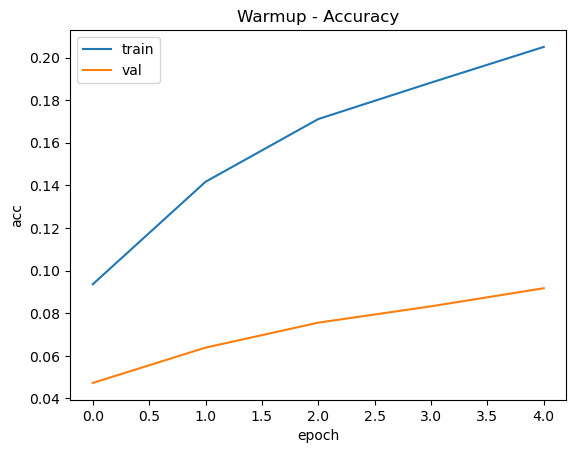

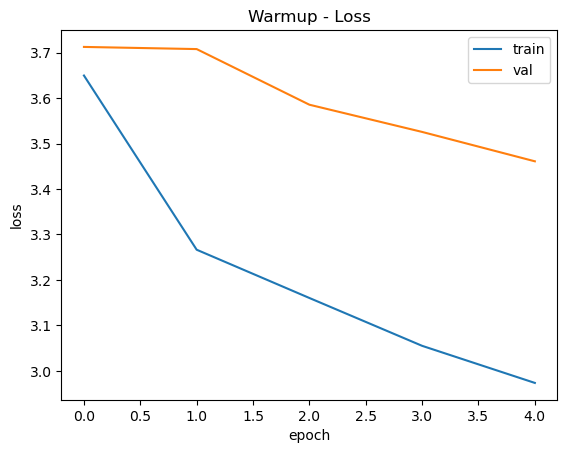

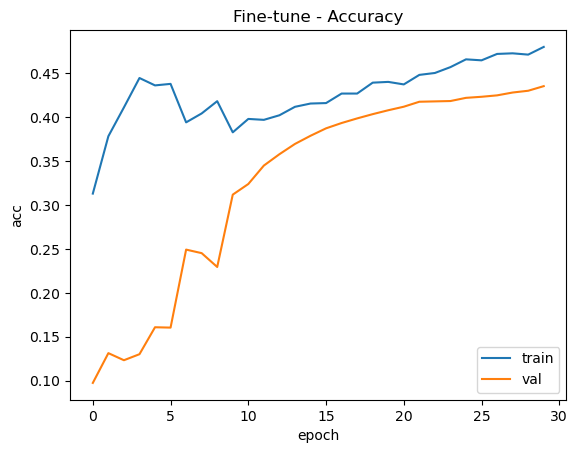

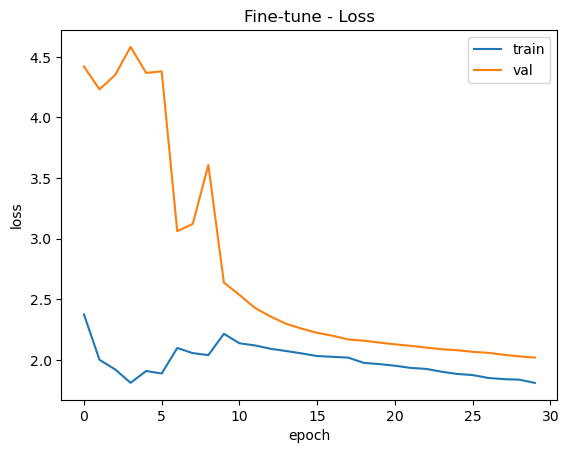

In [11]:
best_tl = "models/effb0_best.keras"
if os.path.exists(best_tl):
    model_tl.load_weights(best_tl)
    print("Loaded best weights:", best_tl)
else:
    print("Best checkpoint not found; using current weights.")

# Evaluate on TEST
test_metrics_tl = model_tl.evaluate(test_ds_tl, verbose=0)
print("EfficientNetB0 Test metrics:", dict(zip(model_tl.metrics_names, test_metrics_tl)))

# Plot curves
def plot_hist(h, title):
    plt.figure(); plt.plot(h.history["accuracy"]); plt.plot(h.history["val_accuracy"])
    plt.title(title + " - Accuracy"); plt.legend(["train","val"]); plt.xlabel("epoch"); plt.ylabel("acc"); plt.show()
    plt.figure(); plt.plot(h.history["loss"]); plt.plot(h.history["val_loss"])
    plt.title(title + " - Loss"); plt.legend(["train","val"]); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()

plot_hist(hist_warmup, "Warmup")
plot_hist(hist_ft, "Fine-tune")